## -----------------------------
## Libraries
## -----------------------------

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


## -----------------------------
## DATA SOURCE (REPRODUCIBLE)
## -----------------------------
## Open Food Facts dataset
## Sample: first 500,000 rows
##-----------------------------

In [4]:
url = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

important_cols = [
    "product_name",
    "sugars_100g",
    "proteins_100g",
    "fat_100g",
    "categories_tags",
    "ingredients_text"
]

chunksize = 100000
target_rows = 500000

clean_data = []
current_rows = 0

for chunk in pd.read_csv(
    url,
    sep="\t",
    compression="gzip",
    chunksize=chunksize,
    on_bad_lines="skip",
    low_memory=False,
    usecols=important_cols
):

    # keep only valid rows
    chunk = chunk.dropna(subset=["sugars_100g", "proteins_100g", "product_name"])

    clean_data.append(chunk)
    current_rows += len(chunk)

    # stop when we reach target
    if current_rows >= target_rows:
        break

# combine everything
df_clean = pd.concat(clean_data, ignore_index=True)

# trim exactly 500k
df_clean = df_clean.head(target_rows)

print("Final clean dataset shape:", df_clean.shape)

Final clean dataset shape: (500000, 6)


In [5]:
print("Sample dataset saved for reproducibility and faster analysis.")

Sample dataset saved for reproducibility and faster analysis.


In [9]:
df_clean.to_csv("openfoodfacts_clean_500k.csv", index=False)

In [21]:
df = pd.read_csv("openfoodfacts_clean_500k.csv")

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   product_name      500000 non-null  object 
 1   categories_tags   192485 non-null  object 
 2   ingredients_text  122003 non-null  object 
 3   fat_100g          498572 non-null  float64
 4   sugars_100g       500000 non-null  float64
 5   proteins_100g     500000 non-null  float64
dtypes: float64(3), object(3)
memory usage: 22.9+ MB


In [23]:
missing_data = df.isnull().sum()
percentage_missing = (missing_data / len(df)) * 100

# Create a DataFrame for better display
missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage Missing': percentage_missing
})

# Filter to show only columns with missing data and sort by percentage
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Percentage Missing', ascending=False)

print("Percentage of missing data in each column:")
display(missing_info)

Percentage of missing data in each column:


,Missing Count,Percentage Missing
ingredients_text,377997,75.5994
categories_tags,307515,61.5030
fat_100g,1428,0.2856


In [24]:
df["categories_tags"] = df["categories_tags"].fillna("unknown")
df["ingredients_text"] = df["ingredients_text"].fillna("unknown")
df["fat_100g"] = df["fat_100g"].fillna(0)

In [15]:
df[["sugars_100g", "proteins_100g", "fat_100g"]].describe()

,sugars_100g,proteins_100g,fat_100g
count,500000.000000,5.000000e+05,5.000000e+05
mean,9.750054,2.102158e+01,4.864728e+01
std,46.710181,5.876646e+03,2.482510e+04
min,0.000000,0.000000e+00,0.000000e+00
25%,0.500000,3.529808e+00,1.764706e+00
50%,2.000000,9.259259e+00,8.100000e+00
75%,10.000000,1.980000e+01,2.180000e+01
max,30029.000000,4.154002e+06,1.755400e+07


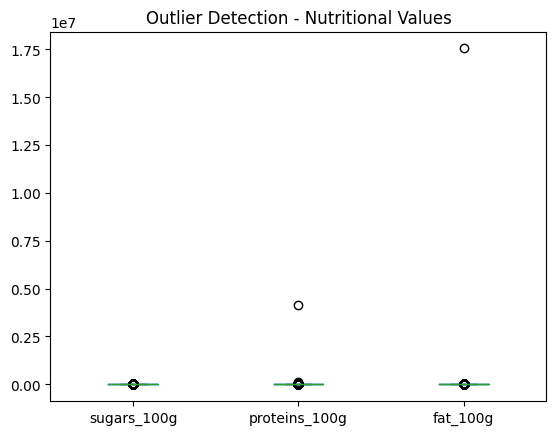

In [25]:

df[["sugars_100g", "proteins_100g", "fat_100g"]].plot(kind="box")
plt.title("Outlier Detection - Nutritional Values")
plt.show()

In [26]:
before = len(df)

df = df[
    (df["sugars_100g"] >= 0) & (df["sugars_100g"] <= 100) &
    (df["proteins_100g"] >= 0) & (df["proteins_100g"] <= 100) &
    (df["fat_100g"] >= 0) & (df["fat_100g"] <= 100)
]

after = len(df)

print(f"Removed {before - after} rows due to invalid nutritional values")

Removed 316 rows due to invalid nutritional values


In [27]:
print(df.shape)
df.head()

(499684, 6)


,product_name,categories_tags,ingredients_text,fat_100g,sugars_100g,proteins_100g
0,Pinto Bean,en:asian-style-ready-meal,unknown,10.20000,4.900000,17.500000
1,Croquetas de bacalao,unknown,unknown,12.10000,1.900000,5.900000
2,Keto & GF Granola,unknown,unknown,54.83871,3.225806,19.677419
3,Ben's Pure Maple Cream,unknown,unknown,30.28000,37.720000,5.680000
4,Guimauve chocolat smarties,unknown,unknown,19.00000,65.000000,5.700000


In [30]:
# Export
df.to_csv("openfoodfacts_clean.csv", index=False)

### Parse categories_tags
### AND
### Extract the first (primary) tag



In [31]:
import re

# Step 1 — Parse the comma-separated tags into a list
df["categories_list"] = df["categories_tags"].str.lower().str.split(",")

# Step 2 — Strip ALL language prefixes (en:, fr:, de:, es: etc.) ← THE KEY FIX
df["categories_list"] = df["categories_list"].apply(
    lambda tags: [re.sub(r"^[a-z]{2}:", "", tag).strip() for tag in tags]
)

# Step 3 — Keyword-based classifier
def assign_category(tags):
    tags = " ".join(tags)
    if any(x in tags for x in ["snack", "chips", "biscuit", "cookie", "cracker", "popcorn", "pretzel"]):
        return "Snacks"
    elif any(x in tags for x in ["beverage", "drink", "soda", "juice", "water", "coffee", "tea", "smoothie", "boisson"]):
        return "Beverages"
    elif any(x in tags for x in ["milk", "cheese", "yogurt", "dairy", "lait", "fromage", "yaourt"]):
        return "Dairy"
    elif any(x in tags for x in ["meat", "fish", "poultry", "sausage", "chicken", "beef", "seafood"]):
        return "Meat & Fish"
    elif any(x in tags for x in ["bread", "cake", "pastry", "bakery", "loaf", "muffin", "croissant"]):
        return "Bakery"
    elif any(x in tags for x in ["cereal", "oat", "grain", "rice", "granola", "porridge"]):
        return "Cereals"
    elif any(x in tags for x in ["chocolate", "candy", "sweet", "dessert", "confection", "sugar"]):
        return "Sweets"
    else:
        return "Other"

df["primary_category"] = df["categories_list"].apply(assign_category)

# Step 4 — Second pass: reclassify "Other" using product name
def infer_from_name(name):
    name = str(name).lower()
    if any(x in name for x in ["cola", "juice", "water", "tea", "drink", "soda"]):
        return "Beverages"
    elif any(x in name for x in ["chocolate", "cookie", "cake", "candy", "sweet"]):
        return "Sweets"
    elif any(x in name for x in ["milk", "cheese", "yogurt", "yoghurt"]):
        return "Dairy"
    elif any(x in name for x in ["chicken", "beef", "fish", "pork", "tuna", "salmon"]):
        return "Meat & Fish"
    elif any(x in name for x in ["bread", "croissant", "baguette", "muffin"]):
        return "Bakery"
    elif any(x in name for x in ["protein", "bar", "shake", "crisp", "chip", "snack"]):
        return "Snacks"
    elif any(x in name for x in ["cereal", "oat", "granola", "grain"]):
        return "Cereals"
    else:
        return "Other"

mask = df["primary_category"] == "Other"
df.loc[mask, "primary_category"] = df.loc[mask, "product_name"].apply(infer_from_name)

# Step 5 — Check results
print(df["primary_category"].value_counts())
print(f"\nOther = {(df['primary_category'] == 'Other').mean()*100:.1f}% of dataset")

primary_category
Other          255482
Beverages       83688
Meat & Fish     56985
Snacks          44089
Dairy           36599
Sweets          13151
Bakery           5273
Cereals          4417
Name: count, dtype: int64

Other = 51.1% of dataset


In [33]:
# Diagnose: what do "Other" products actually look like?
other_df = df[df["primary_category"] == "Other"]

print("=== Sample product names in 'Other' ===")
print(other_df["product_name"].sample(20).tolist())

print("\n=== Sample categories_tags in 'Other' ===")
print(other_df["categories_tags"].sample(20).tolist())

print("\n=== How many 'Other' had no categories_tags at all? ===")
no_tags = other_df[other_df["categories_tags"] == "unknown"]
print(f"{len(no_tags):,} out of {len(other_df):,} ({len(no_tags)/len(other_df)*100:.1f}%)")

=== Sample product names in 'Other' ===
['Cassava Flour Tortillas', '4.5 Inch Flour Tortilla', 'Noix de cajou Truffe', 'Brie de Maux AOP', 'Sauce piquante', "L'affine Végétal", 'Salsa Cantina Style Habanero', 'Atún', 'Salade mixte', 'Pinapple And Grapefruit Crush', 'Istara ossau iraty', 'Lomo adobado de cerdo iberico', 'Laitue Iceberg', 'Solomillo de pollo crujiente', 'Farro', 'Salsiccia stagionata bianca sv', 'Douchou', 'Croustillants à la provençale', 'Porta Pepperoni Pizza', 'Mélange Babylone']

=== Sample categories_tags in 'Other' ===
['unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'fr:chataignes-d-eau', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'en:energy-bites']

=== How many 'Other' had no categories_tags at all? ===
237,486 out of 255,482 (93.0%)


In [35]:
def infer_from_name(name):
    name = str(name).lower()

    # Beverages
    if any(x in name for x in ["cola", "juice", "water", "tea", "drink", "soda",
                                 "smoothie", "coffee", "latte", "espresso", "milk",
                                 "jus", "eau", "boisson", "lait"]):
        return "Beverages"

    # Dairy
    elif any(x in name for x in ["cheese", "yogurt", "yoghurt", "brie", "camembert",
                                   "cheddar", "mozzarella", "butter", "cream", "fromage",
                                   "yaourt", "lait", "ossau", "istara", "affine"]):
        return "Dairy"

    # Meat & Fish
    elif any(x in name for x in ["chicken", "beef", "fish", "pork", "tuna", "salmon",
                                   "turkey", "lamb", "shrimp", "prawn", "bacon", "ham",
                                   "sausage", "pepperoni", "salami", "lomo", "atun",
                                   "atún", "pollo", "cerdo", "solomillo", "salsiccia",
                                   "iberico", "chorizo", "pescado"]):
        return "Meat & Fish"

    # Bakery
    elif any(x in name for x in ["bread", "croissant", "baguette", "muffin", "tortilla",
                                   "waffle", "pancake", "biscuit", "roll", "loaf",
                                   "flatbread", "pita", "naan", "pretzel", "bagel",
                                   "brioche", "pain", "tarte", "pizza", "flan"]):
        return "Bakery"

    # Cereals & Grains
    elif any(x in name for x in ["cereal", "oat", "granola", "grain", "rice", "farro",
                                   "quinoa", "wheat", "barley", "millet", "porridge",
                                   "flour", "pasta", "noodle", "couscous", "maize"]):
        return "Cereals"

    # Sweets
    elif any(x in name for x in ["chocolate", "cookie", "cake", "candy", "sweet",
                                   "brownie", "donut", "macaron", "caramel", "fudge",
                                   "truffe", "truffle", "nougat", "praline", "bonbon"]):
        return "Sweets"

    # Snacks
    elif any(x in name for x in ["protein", "bar", "shake", "crisp", "chip", "snack",
                                   "popcorn", "cracker", "pretzel", "nut", "noix",
                                   "cashew", "almond", "peanut", "cajou", "croustillant"]):
        return "Snacks"

    # Produce (NEW BUCKET)
    elif any(x in name for x in ["salad", "salade", "vegetable", "fruit", "tomato",
                                   "lettuce", "laitue", "spinach", "carrot", "pepper",
                                   "onion", "garlic", "mushroom", "avocado", "mango",
                                   "apple", "banana", "berry", "pineapple", "grapefruit",
                                   "mixte", "legume"]):
        return "Produce"

    # Condiments (NEW BUCKET)
    elif any(x in name for x in ["sauce", "salsa", "dressing", "vinegar", "mustard",
                                   "ketchup", "mayo", "mayonnaise", "marinade", "pesto",
                                   "hummus", "dip", "spread", "jam", "honey", "sirop"]):
        return "Condiments"

    else:
        return "Other"

# Re-apply ONLY on "Other" rows
mask = df["primary_category"] == "Other"
df.loc[mask, "primary_category"] = (
    df.loc[mask, "product_name"].apply(infer_from_name)
)

# Check results
print(df["primary_category"].value_counts())
print(f"\nOther = {(df['primary_category'] == 'Other').mean()*100:.1f}% of dataset")

primary_category
Other          169691
Beverages       89767
Meat & Fish     75992
Snacks          49428
Dairy           45414
Bakery          16412
Sweets          16406
Condiments      14512
Produce         13217
Cereals          8845
Name: count, dtype: int64

Other = 34.0% of dataset


In [36]:
# Final export — this is your clean, classified dataset
df.to_csv("openfoodfacts_clean.csv", index=False)

print("=== STORY 1 & 2 COMPLETE ===")
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nCategory breakdown:")
print(df["primary_category"].value_counts())
print(f"\nNamed categories: {(df['primary_category'] != 'Other').sum():,} products")
print(f"Classifiable rate: {(df['primary_category'] != 'Other').mean()*100:.1f}%")

=== STORY 1 & 2 COMPLETE ===
Total rows: 499,684
Columns: ['product_name', 'categories_tags', 'ingredients_text', 'fat_100g', 'sugars_100g', 'proteins_100g', 'categories_list', 'primary_category']

Category breakdown:
primary_category
Other          169691
Beverages       89767
Meat & Fish     75992
Snacks          49428
Dairy           45414
Bakery          16412
Sweets          16406
Condiments      14512
Produce         13217
Cereals          8845
Name: count, dtype: int64

Named categories: 329,993 products
Classifiable rate: 66.0%
